In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error, r2_score


df = pd.read_csv("/content/drive/MyDrive/wfp_food_prices_nga.csv", skiprows=[1])
df["date"] = pd.to_datetime(df["date"])
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.dropna(subset=["price"])

commodity, market, unit = "Maize (white)", "Ibadan", "100 KG"
series = df[(df["commodity"]==commodity) & (df["market"]==market) & (df["unit"]==unit)].sort_values("date")
series = series.set_index("date")["price"]
series.index = series.index.to_period("M").to_timestamp()
series = series.asfreq("MS").interpolate()

In [7]:
train = series[:-6]
test = series[-6:]
naive_pred = pd.Series([train.iloc[-1]] * len(test), index=test.index)
naive_mape = mean_absolute_percentage_error(test, naive_pred)
naive_r2 = r2_score(test, naive_pred)

# Seasonal-naive: use the same month from one year ealier
seasonal_naive_pred = pd.Series(
    [series.get(d - pd.DateOffset(years=1), np.nan) for d in test.index],
    index=test.index
)
sn_mape = mean_absolute_percentage_error(test, seasonal_naive_pred)
sn_r2 = r2_score(test, seasonal_naive_pred)

print(f"Naive - MAPE: {naive_mape*100:.2f}% R²: {naive_r2:.3f}")
print(f"Seasonal-Naive - MAPE: {sn_mape*100:.2f}% R²: {sn_r2:.3f}")

Naive - MAPE: 8.90% R²: -0.149
Seasonal-Naive - MAPE: 11.12% R²: -1.051


In [8]:
n_test = 24    #last 24 months, one-step-ahead forecast each time
import statsmodels.tsa.arima.model as ARIMA

records = []
for i in range(len(series) - n_test, len(series)):
  train_window = series.iloc[:i]
  actual = series.iloc[i]

  naive_pred = train_window.iloc[-1]
  arima_pred = np.nan # Initialize arima_pred

  try:
    arima_fit = ARIMA.ARIMA(train_window, order=(1,1,1)).fit()
    arima_pred = arima_fit.forecast(steps=1).iloc[0]
  except Exception:
    # If ARIMA fails, arima_pred remains np.nan
    pass

  records.append({"date": series.index[i], "actual": actual, "naive": naive_pred, "arima": arima_pred})

# Calculate metrics after the loop finishes
wf_df = pd.DataFrame(records).set_index("date").dropna()

naive_mape_wf = mean_absolute_percentage_error(wf_df["actual"], wf_df["naive"])
naive_r2_wf = r2_score(wf_df["actual"], wf_df["naive"])
arima_mape_wf = mean_absolute_percentage_error(wf_df["actual"], wf_df["arima"])
arima_r2_wf = r2_score(wf_df["actual"], wf_df["arima"])

print(f"Naive (walk-forward, 1-step) - MAPE: {naive_mape_wf*100:.2f}% R²: {naive_r2_wf:.3f}")
print(f"ARIMA (walk-forward, 1-step) - MAPE: {arima_mape_wf*100:.2f}% R²: {arima_r2_wf:.3f}")

Naive (walk-forward, 1-step) - MAPE: 4.34% R²: 0.242
ARIMA (walk-forward, 1-step) - MAPE: 4.38% R²: 0.361


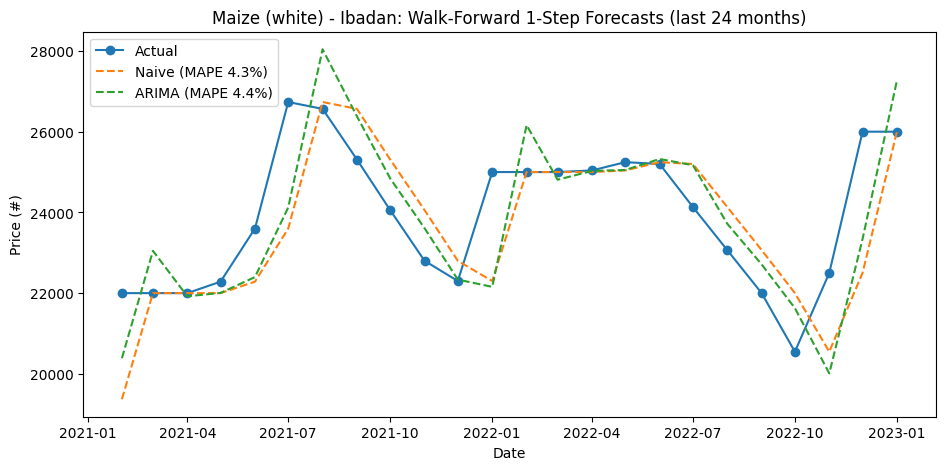

In [9]:
plt.figure(figsize=(11,5))
plt.plot(wf_df.index, wf_df["actual"], label="Actual", marker="o")
plt.plot(wf_df.index, wf_df["naive"], label=f"Naive (MAPE {naive_mape_wf*100:.1f}%)", linestyle="--")
plt.plot(wf_df.index, wf_df["arima"], label=f"ARIMA (MAPE {arima_mape_wf*100:.1f}%)", linestyle="--")
plt.legend()
plt.title(f"{commodity} - {market}: Walk-Forward 1-Step Forecasts (last 24 months)")
plt.xlabel("Date"); plt.ylabel("Price (#)")
plt.show()